<a href="https://colab.research.google.com/github/Rklearns/BanglaYield-CP/blob/main/yieldML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# General

In [3]:
# Imports
import numpy as np
import pandas as pd

import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Define url to data
resource_folder = 'https://raw.githubusercontent.com/Drinkler/Yield-Prediction/main/res'

pesticides_url = resource_folder + '/pesticides.csv'
rainfall_url = resource_folder + '/rainfall.csv'
temperature_url = resource_folder + '/temp.csv'
yield_url = resource_folder + '/yield.csv'

In [5]:
# Load data
pesticides_data = pd.read_csv(pesticides_url, sep=',')
rainfall_data = pd.read_csv(rainfall_url, sep=', ')
temperature_data = pd.read_csv(temperature_url, sep=', ')
yield_data = pd.read_csv(yield_url, sep=',')

/tmp/ipykernel_445/1280508307.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  rainfall_data = pd.read_csv(rainfall_url, sep=', ')
/tmp/ipykernel_445/1280508307.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  temperature_data = pd.read_csv(temperature_url, sep=', ')


#Data Preparation


## Rainfall data

In [6]:
rainfall_data

,Rainfall - (MM),Year,Statistics,Country,ISO3
0,55.74480,1901,Jan Average,Afghanistan,AFG
1,13.94800,1901,Feb Average,Afghanistan,AFG
2,43.84640,1901,Mar Average,Afghanistan,AFG
3,26.96100,1901,Apr Average,Afghanistan,AFG
4,52.95790,1901,May Average,Afghanistan,AFG
...,...,...,...,...,...
272827,2.03926,2016,Aug Average,Zimbabwe,ZWE
272828,0.48070,2016,Sep Average,Zimbabwe,ZWE
272829,9.13410,2016,Oct Average,Zimbabwe,ZWE
272830,72.95080,2016,Nov Average,Zimbabwe,ZWE


In [7]:
rainfall_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272832 entries, 0 to 272831
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Rainfall - (MM)  272832 non-null  float64
 1   Year             272832 non-null  int64  
 2   Statistics       272832 non-null  object 
 3   Country          272832 non-null  object 
 4   ISO3             272832 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 10.4+ MB


In [8]:
rainfall_data.describe()

,Rainfall - (MM),Year
count,272832.000000,272832.000000
mean,103.470868,1958.500000
std,113.231867,33.485133
min,0.000000,1901.000000
25%,24.168375,1929.750000
50%,66.431550,1958.500000
75%,149.647250,1987.250000
max,2699.190000,2016.000000


In [9]:
# Number of countries
len(rainfall_data['Country'].unique())

196

In [10]:
# Number of years (1901 - 2016)
len(rainfall_data['Year'].unique())

116

In [11]:
# One year from Afghanistan
rainfall_data.head(12)

,Rainfall - (MM),Year,Statistics,Country,ISO3
0,55.74480,1901,Jan Average,Afghanistan,AFG
1,13.94800,1901,Feb Average,Afghanistan,AFG
2,43.84640,1901,Mar Average,Afghanistan,AFG
3,26.96100,1901,Apr Average,Afghanistan,AFG
4,52.95790,1901,May Average,Afghanistan,AFG
5,16.64650,1901,Jun Average,Afghanistan,AFG
6,7.38656,1901,Jul Average,Afghanistan,AFG
7,0.59306,1901,Aug Average,Afghanistan,AFG
8,4.82593,1901,Sep Average,Afghanistan,AFG
9,11.49720,1901,Oct Average,Afghanistan,AFG


In [12]:
# Rain data in years for each country
rainfall_df = rainfall_data.groupby(['Year', 'Country', 'ISO3'], as_index=False, axis=0).sum()
rainfall_df

/tmp/ipykernel_445/3395671517.py:2: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  rainfall_df = rainfall_data.groupby(['Year', 'Country', 'ISO3'], as_index=False, axis=0).sum()


,Year,Country,ISO3,Rainfall - (MM),Statistics
0,1901,Afghanistan,AFG,250.92364,Jan AverageFeb AverageMar AverageApr AverageMa...
1,1901,Albania,ALB,1244.13740,Jan AverageFeb AverageMar AverageApr AverageMa...
2,1901,Algeria,DZA,113.45278,Jan AverageFeb AverageMar AverageApr AverageMa...
3,1901,Andorra,AND,871.31150,Jan AverageFeb AverageMar AverageApr AverageMa...
4,1901,Angola,AGO,931.01022,Jan AverageFeb AverageMar AverageApr AverageMa...
...,...,...,...,...,...
22731,2016,Venezuela,VEN,1844.70330,Jan AverageFeb AverageMar AverageApr AverageMa...
22732,2016,Vietnam,VNM,1988.86180,Jan AverageFeb AverageMar AverageApr AverageMa...
22733,2016,Yemen,YEM,171.48137,Jan AverageFeb AverageMar AverageApr AverageMa...
22734,2016,Zambia,ZMB,803.47810,Jan AverageFeb AverageMar AverageApr AverageMa...


## Temperature data

In [13]:
temperature_data

,Temperature - (Celsius),Year,Statistics,Country,ISO3
0,-0.03780,1901,Jan Average,Afghanistan,AFG
1,2.42348,1901,Feb Average,Afghanistan,AFG
2,9.36230,1901,Mar Average,Afghanistan,AFG
3,13.55640,1901,Apr Average,Afghanistan,AFG
4,18.15090,1901,May Average,Afghanistan,AFG
...,...,...,...,...,...
272827,18.75550,2016,Aug Average,Zimbabwe,ZWE
272828,22.99190,2016,Sep Average,Zimbabwe,ZWE
272829,25.86640,2016,Oct Average,Zimbabwe,ZWE
272830,25.85150,2016,Nov Average,Zimbabwe,ZWE


In [14]:
temperature_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272832 entries, 0 to 272831
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Temperature - (Celsius)  272832 non-null  float64
 1   Year                     272832 non-null  int64  
 2   Statistics               272832 non-null  object 
 3   Country                  272832 non-null  object 
 4   ISO3                     272832 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 10.4+ MB


In [15]:
temperature_data.describe()

,Temperature - (Celsius),Year
count,272832.000000,272832.000000
mean,18.631498,1958.500000
std,10.248635,33.485133
min,-34.121000,1901.000000
25%,13.231575,1929.750000
50%,22.736300,1958.500000
75%,25.797700,1987.250000
max,38.566900,2016.000000


In [16]:
# Number of countries
len(temperature_data['Country'].unique())

196

In [17]:
# Number of years (1901 - 2016)
len(temperature_data['Year'].unique())

116

In [18]:
# One year from Afghanistan
temperature_data.head(12)

,Temperature - (Celsius),Year,Statistics,Country,ISO3
0,-0.03780,1901,Jan Average,Afghanistan,AFG
1,2.42348,1901,Feb Average,Afghanistan,AFG
2,9.36230,1901,Mar Average,Afghanistan,AFG
3,13.55640,1901,Apr Average,Afghanistan,AFG
4,18.15090,1901,May Average,Afghanistan,AFG
5,22.17270,1901,Jun Average,Afghanistan,AFG
6,25.37870,1901,Jul Average,Afghanistan,AFG
7,23.66520,1901,Aug Average,Afghanistan,AFG
8,19.46550,1901,Sep Average,Afghanistan,AFG
9,11.28370,1901,Oct Average,Afghanistan,AFG


In [19]:
temperature_df = temperature_data.groupby(
    ['Year', 'Country', 'ISO3'],
    as_index=False
).mean(numeric_only=True)
temperature_df

,Year,Country,ISO3,Temperature - (Celsius)
0,1901,Afghanistan,AFG,13.172872
1,1901,Albania,ALB,11.030938
2,1901,Algeria,DZA,22.290008
3,1901,Andorra,AND,9.960649
4,1901,Angola,AGO,21.365725
...,...,...,...,...
22731,2016,Venezuela,VEN,26.478200
22732,2016,Vietnam,VNM,25.073158
22733,2016,Yemen,YEM,24.221200
22734,2016,Zambia,ZMB,22.737050



## Yield data

In [20]:
yield_data

,Domain,Area,Element,Item,Year,Unit,Value
0,Crops,Afghanistan,Yield,Barley,1961,hg/ha,10800
1,Crops,Afghanistan,Yield,Barley,1962,hg/ha,10800
2,Crops,Afghanistan,Yield,Barley,1963,hg/ha,10800
3,Crops,Afghanistan,Yield,Barley,1964,hg/ha,10857
4,Crops,Afghanistan,Yield,Barley,1965,hg/ha,10857
...,...,...,...,...,...,...,...
63686,Crops,Zimbabwe,Yield,Wheat,2015,hg/ha,20486
63687,Crops,Zimbabwe,Yield,Wheat,2016,hg/ha,19013
63688,Crops,Zimbabwe,Yield,Wheat,2017,hg/ha,17542
63689,Crops,Zimbabwe,Yield,Wheat,2018,hg/ha,16379


In [21]:
yield_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63691 entries, 0 to 63690
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Domain   63691 non-null  object
 1   Area     63691 non-null  object
 2   Element  63691 non-null  object
 3   Item     63691 non-null  object
 4   Year     63691 non-null  int64 
 5   Unit     63691 non-null  object
 6   Value    63691 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 3.4+ MB


In [22]:
yield_data.describe()

,Year,Value
count,63691.000000,6.369100e+04
mean,1992.332669,8.581113e+04
std,16.888797,1.008880e+05
min,1961.000000,0.000000e+00
25%,1978.000000,1.770700e+04
50%,1994.000000,4.705900e+04
75%,2007.000000,1.185070e+05
max,2019.000000,2.236842e+06


In [23]:
# Number of countries
len(yield_data['Area'].unique())

203

In [24]:
# Number of years (1961 - 2019)
len(yield_data['Year'].unique())

59

In [25]:
# Remove unnecessary columns
yield_df = yield_data.drop(['Domain', 'Element'], axis=1)
yield_df

,Area,Item,Year,Unit,Value
0,Afghanistan,Barley,1961,hg/ha,10800
1,Afghanistan,Barley,1962,hg/ha,10800
2,Afghanistan,Barley,1963,hg/ha,10800
3,Afghanistan,Barley,1964,hg/ha,10857
4,Afghanistan,Barley,1965,hg/ha,10857
...,...,...,...,...,...
63686,Zimbabwe,Wheat,2015,hg/ha,20486
63687,Zimbabwe,Wheat,2016,hg/ha,19013
63688,Zimbabwe,Wheat,2017,hg/ha,17542
63689,Zimbabwe,Wheat,2018,hg/ha,16379


## Pesticides data

In [26]:
pesticides_data

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1990,tonnes,121
1,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1991,tonnes,121
2,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1992,tonnes,121
3,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1993,tonnes,121
4,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1994,tonnes,201
...,...,...,...,...,...,...,...
4784,Pesticides Use,Zimbabwe,Agricultural Use,Pesticides (total),2014,tonnes,2185
4785,Pesticides Use,Zimbabwe,Agricultural Use,Pesticides (total),2015,tonnes,2185
4786,Pesticides Use,Zimbabwe,Agricultural Use,Pesticides (total),2016,tonnes,2185
4787,Pesticides Use,Zimbabwe,Agricultural Use,Pesticides (total),2017,tonnes,2185


In [27]:
pesticides_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4789 entries, 0 to 4788
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Domain   4789 non-null   object
 1   Area     4789 non-null   object
 2   Element  4789 non-null   object
 3   Item     4789 non-null   object
 4   Year     4789 non-null   int64 
 5   Unit     4789 non-null   object
 6   Value    4789 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 262.0+ KB


In [28]:
pesticides_data.describe()

,Year,Value
count,4789.000000,4.789000e+03
mean,2004.142619,2.894718e+04
std,8.302595,1.627207e+05
min,1990.000000,0.000000e+00
25%,1997.000000,9.900000e+01
50%,2004.000000,1.221000e+03
75%,2011.000000,7.420000e+03
max,2018.000000,1.815690e+06


In [29]:
# Number of countries
len(pesticides_data['Area'].unique())

172

In [30]:
# Number of years (1990 - 2018)
len(pesticides_data['Year'].unique())

29

In [31]:
# Remove unnecessary columns
pesticides_df = pesticides_data.drop(['Domain', 'Element'], axis=1)
pesticides_df

,Area,Item,Year,Unit,Value
0,Albania,Pesticides (total),1990,tonnes,121
1,Albania,Pesticides (total),1991,tonnes,121
2,Albania,Pesticides (total),1992,tonnes,121
3,Albania,Pesticides (total),1993,tonnes,121
4,Albania,Pesticides (total),1994,tonnes,201
...,...,...,...,...,...
4784,Zimbabwe,Pesticides (total),2014,tonnes,2185
4785,Zimbabwe,Pesticides (total),2015,tonnes,2185
4786,Zimbabwe,Pesticides (total),2016,tonnes,2185
4787,Zimbabwe,Pesticides (total),2017,tonnes,2185


## Merging

In [32]:
rainfall_df.rename({'Rainfall - (MM)': 'Rainfall (mm)'}, axis=1, inplace=True)

In [33]:
temperature_df.rename({'Temperature - (Celsius)': 'Temperature (Celsius)'}, axis=1, inplace=True)

In [34]:
yield_df.rename({'Area': 'Country', 'Value': 'Yield (hg/ha)'}, axis=1, inplace=True)
yield_df.drop('Unit', axis=1, inplace=True)

In [35]:
pesticides_df.rename({'Area': 'Country', 'Value': 'Pesticides (tonnes)'}, axis=1, inplace=True)
pesticides_df.drop(['Unit', 'Item'], axis=1, inplace=True)

In [36]:
rain_temp_df = pd.merge(rainfall_df, temperature_df, on=['Country', 'Year', 'ISO3'])
rain_temp_yield_df = pd.merge(rain_temp_df, yield_df, on=['Country', 'Year'])
rain_temp_yield_pest_df = pd.merge(rain_temp_yield_df, pesticides_df, on=['Country', 'Year'])
rain_temp_yield_pest_df.drop('ISO3', axis=1, inplace=True)
data = rain_temp_yield_pest_df[['Year', 'Country', 'Item', 'Rainfall (mm)', 'Temperature (Celsius)', 'Pesticides (tonnes)', 'Yield (hg/ha)']]
data

,Year,Country,Item,Rainfall (mm),Temperature (Celsius),Pesticides (tonnes),Yield (hg/ha)
0,1990,Albania,Barley,812.23450,12.051221,121,10000
1,1990,Albania,Carrots and turnips,812.23450,12.051221,121,150000
2,1990,Albania,Cauliflowers and broccoli,812.23450,12.051221,121,171429
3,1990,Albania,Garlic,812.23450,12.051221,121,65000
4,1990,Albania,Maize,812.23450,12.051221,121,36613
...,...,...,...,...,...,...,...
25224,2016,Zimbabwe,Maize,455.13295,22.310167,2185,4405
25225,2016,Zimbabwe,Oats,455.13295,22.310167,2185,20505
25226,2016,Zimbabwe,Potatoes,455.13295,22.310167,2185,51792
25227,2016,Zimbabwe,Sweet potatoes,455.13295,22.310167,2185,27283


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25229 entries, 0 to 25228
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   25229 non-null  int64  
 1   Country                25229 non-null  object 
 2   Item                   25229 non-null  object 
 3   Rainfall (mm)          25229 non-null  float64
 4   Temperature (Celsius)  25229 non-null  float64
 5   Pesticides (tonnes)    25229 non-null  int64  
 6   Yield (hg/ha)          25229 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.3+ MB


In [38]:
data.describe()

,Year,Rainfall (mm),Temperature (Celsius),Pesticides (tonnes),Yield (hg/ha)
count,25229.000000,25229.000000,25229.000000,2.522900e+04,2.522900e+04
mean,2003.374727,973.384508,16.688241,3.494096e+04,9.514574e+04
std,7.681975,721.249911,8.008750,1.750313e+05,1.059950e+05
min,1990.000000,16.703610,-7.166322,0.000000e+00,0.000000e+00
25%,1997.000000,486.113000,9.981922,5.670000e+02,2.080800e+04
50%,2003.000000,756.758400,18.222467,2.803000e+03,5.444700e+04
75%,2010.000000,1347.522400,23.992408,1.375600e+04,1.343930e+05
max,2016.000000,4999.686400,29.541075,1.815690e+06,1.705000e+06


In [39]:
# Number of countries
len(data.Country.unique())

135

In [40]:
# Number of years (1990 - 2016)
len(data.Year.unique())

27

# Data Exploration

## Rainfall data

In [41]:
rainfall_df

,Year,Country,ISO3,Rainfall (mm),Statistics
0,1901,Afghanistan,AFG,250.92364,Jan AverageFeb AverageMar AverageApr AverageMa...
1,1901,Albania,ALB,1244.13740,Jan AverageFeb AverageMar AverageApr AverageMa...
2,1901,Algeria,DZA,113.45278,Jan AverageFeb AverageMar AverageApr AverageMa...
3,1901,Andorra,AND,871.31150,Jan AverageFeb AverageMar AverageApr AverageMa...
4,1901,Angola,AGO,931.01022,Jan AverageFeb AverageMar AverageApr AverageMa...
...,...,...,...,...,...
22731,2016,Venezuela,VEN,1844.70330,Jan AverageFeb AverageMar AverageApr AverageMa...
22732,2016,Vietnam,VNM,1988.86180,Jan AverageFeb AverageMar AverageApr AverageMa...
22733,2016,Yemen,YEM,171.48137,Jan AverageFeb AverageMar AverageApr AverageMa...
22734,2016,Zambia,ZMB,803.47810,Jan AverageFeb AverageMar AverageApr AverageMa...


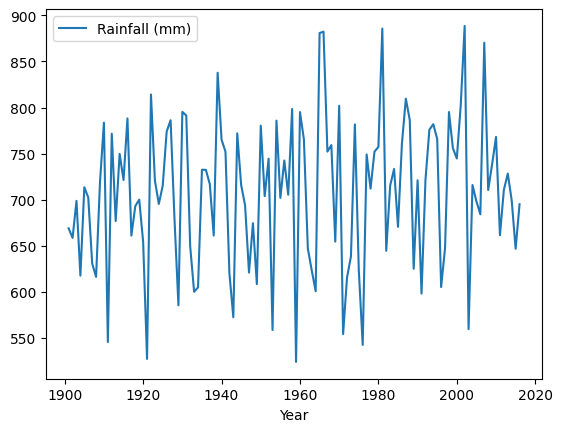

In [42]:
rainfall_df.loc[rainfall_df['Country'] == 'Germany'].groupby('Year').mean(numeric_only=True).plot()
plt.show()

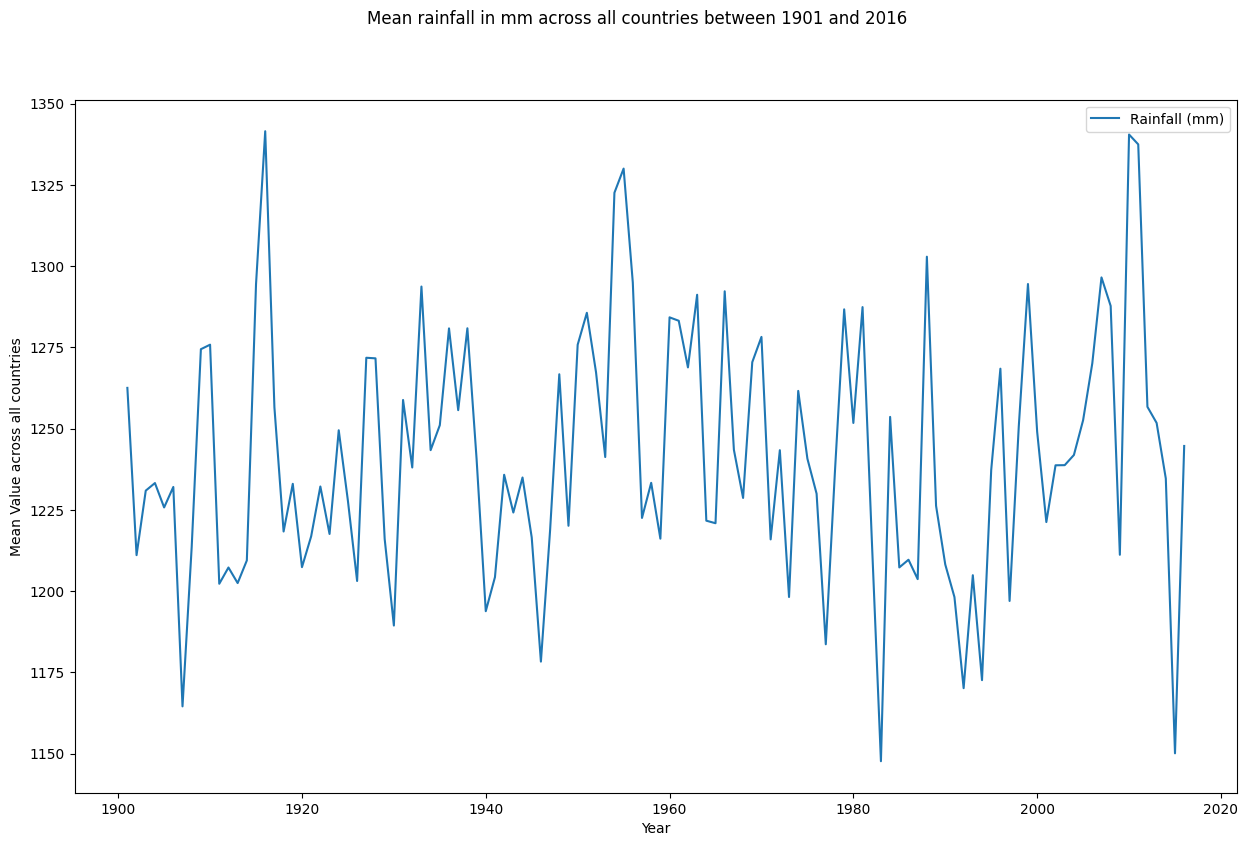

In [43]:
# prepare data
temp_data = rainfall_df.groupby('Year').mean(numeric_only=True)

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean rainfall in mm across all countries between 1901 and 2016')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

## Temperature data

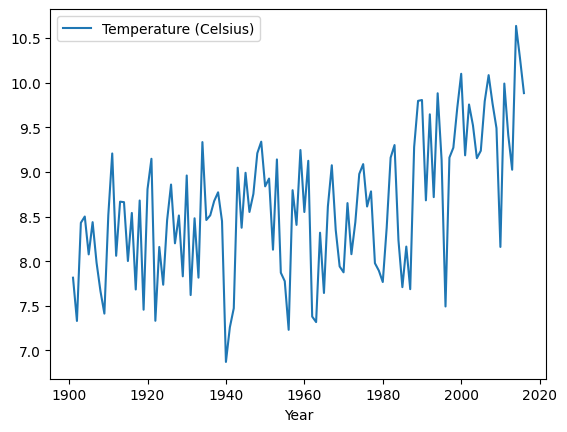

In [44]:
temperature_df.loc[temperature_df['Country'] == 'Germany'].groupby('Year').mean(numeric_only=True).plot()
plt.show()

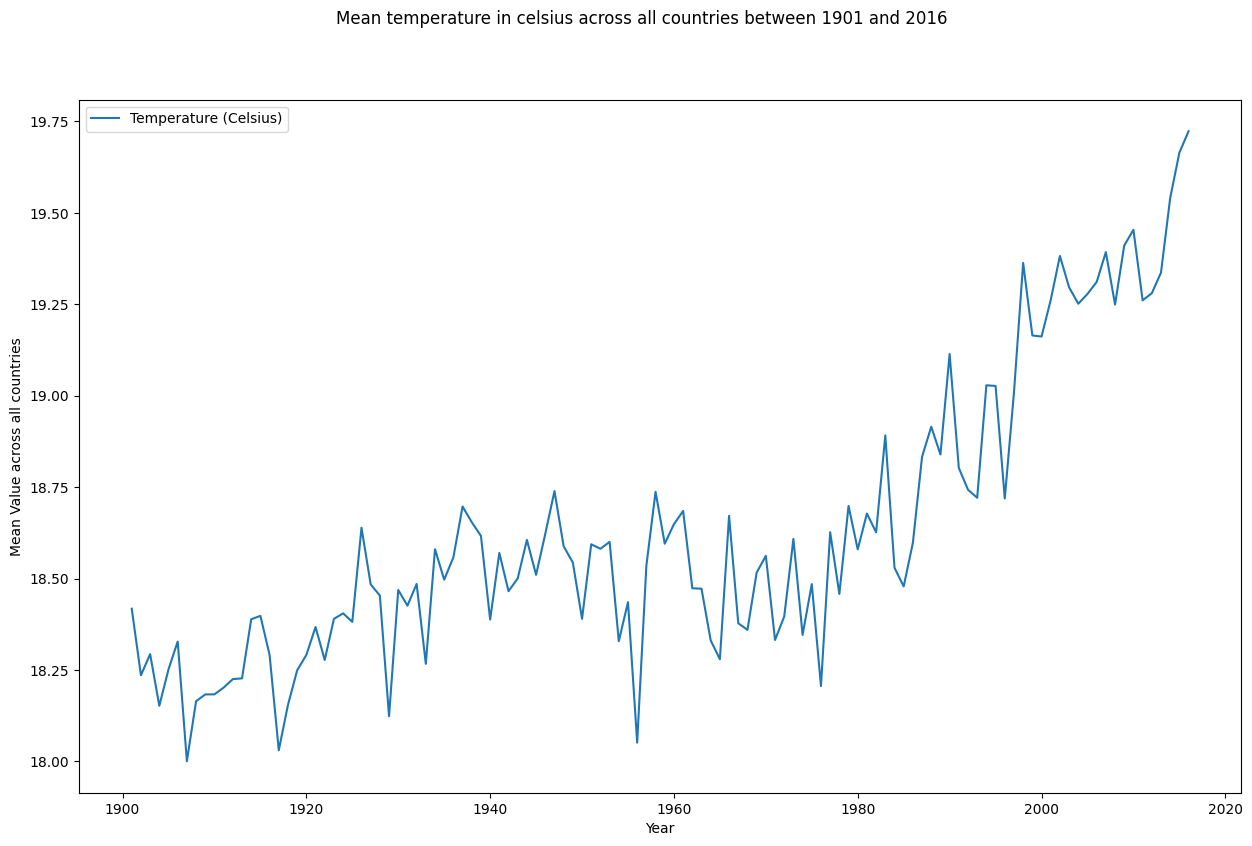

In [45]:
# prepare data
temp_data = temperature_df.groupby('Year').mean(numeric_only=True)

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean temperature in celsius across all countries between 1901 and 2016')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

## Yield data

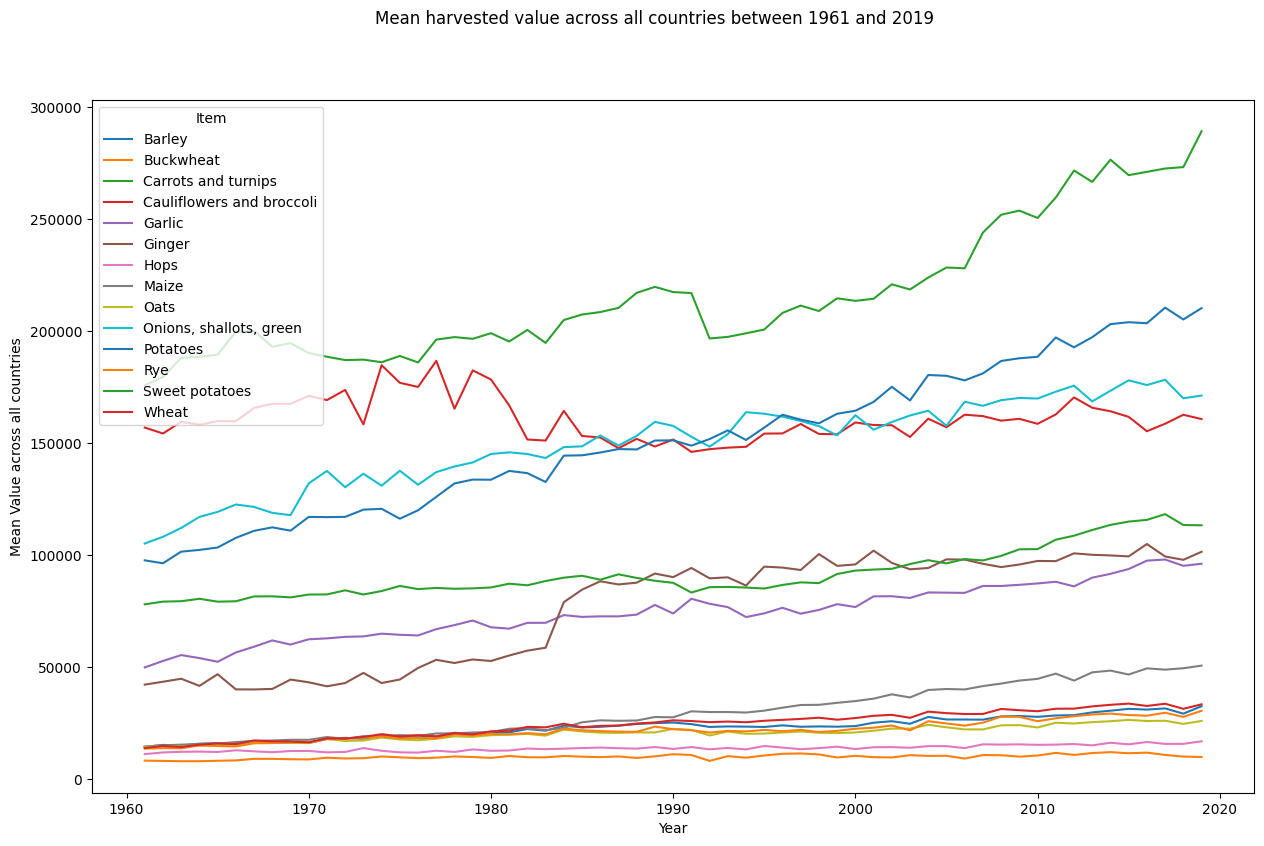

In [46]:
# prepare data
yield_mean = yield_data.groupby(['Year', 'Item']).mean(numeric_only=True)

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean harvested value across all countries between 1961 and 2019')

yield_mean['Value'].unstack().plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

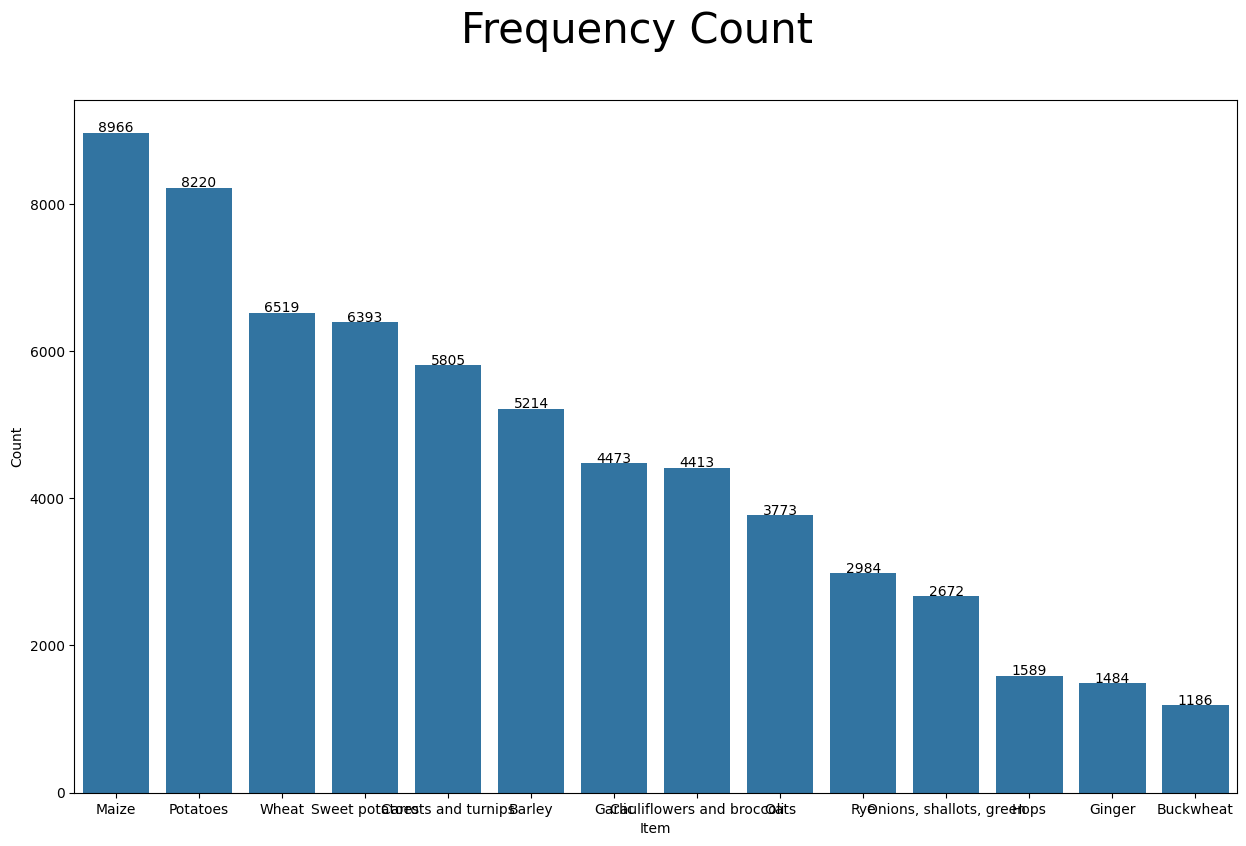

In [47]:
fig, axs = plt.subplots(1,1, figsize=(15,9))
fig.suptitle('Frequency Count', size=30)

temp_df = yield_data['Item'].value_counts().reset_index()
temp_df.columns = ['Item', 'Count']

g = sns.barplot(x='Item', y='Count', data=temp_df, ax=axs)

for i, row in temp_df.iterrows():
    g.text(i, row['Count'] + 10, row['Count'], ha='center')

axs.set_xlabel('Item')
axs.set_ylabel('Count')

plt.show()

## Pesticide data

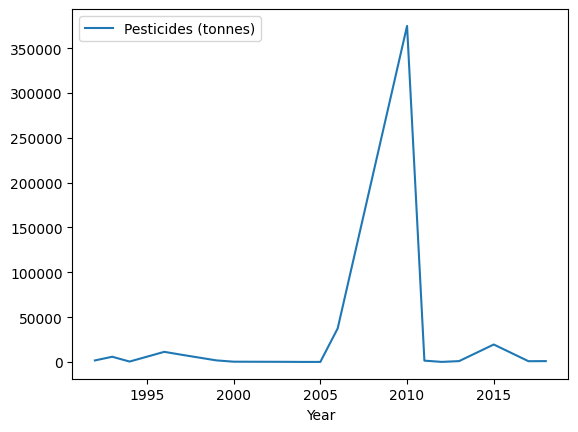

In [48]:
pesticides_df.loc[temperature_df['Country'] == 'Germany'].groupby('Year').mean(numeric_only=True).plot()
plt.show()


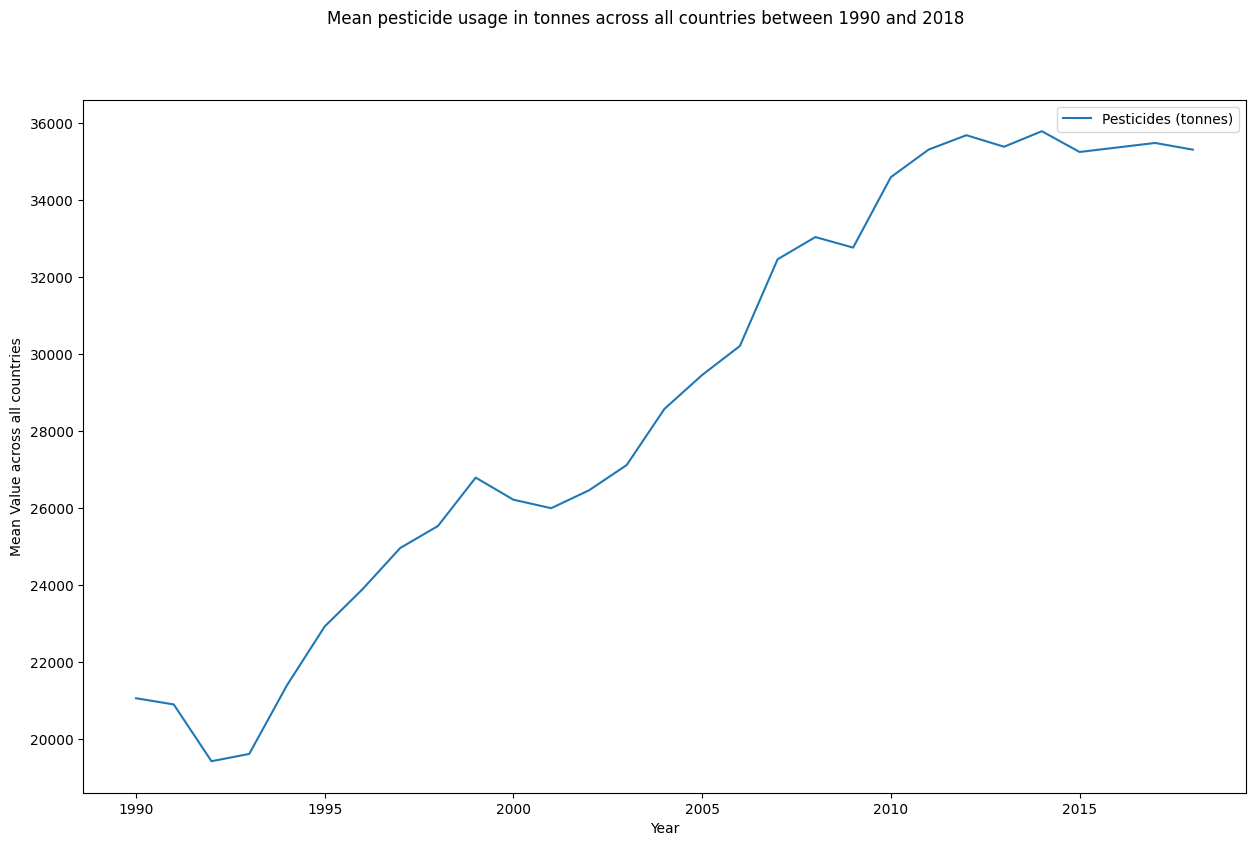

In [49]:
# prepare data
temp_data = pesticides_df.groupby('Year').mean(numeric_only=True)

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean pesticide usage in tonnes across all countries between 1990 and 2018')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

## Merged data

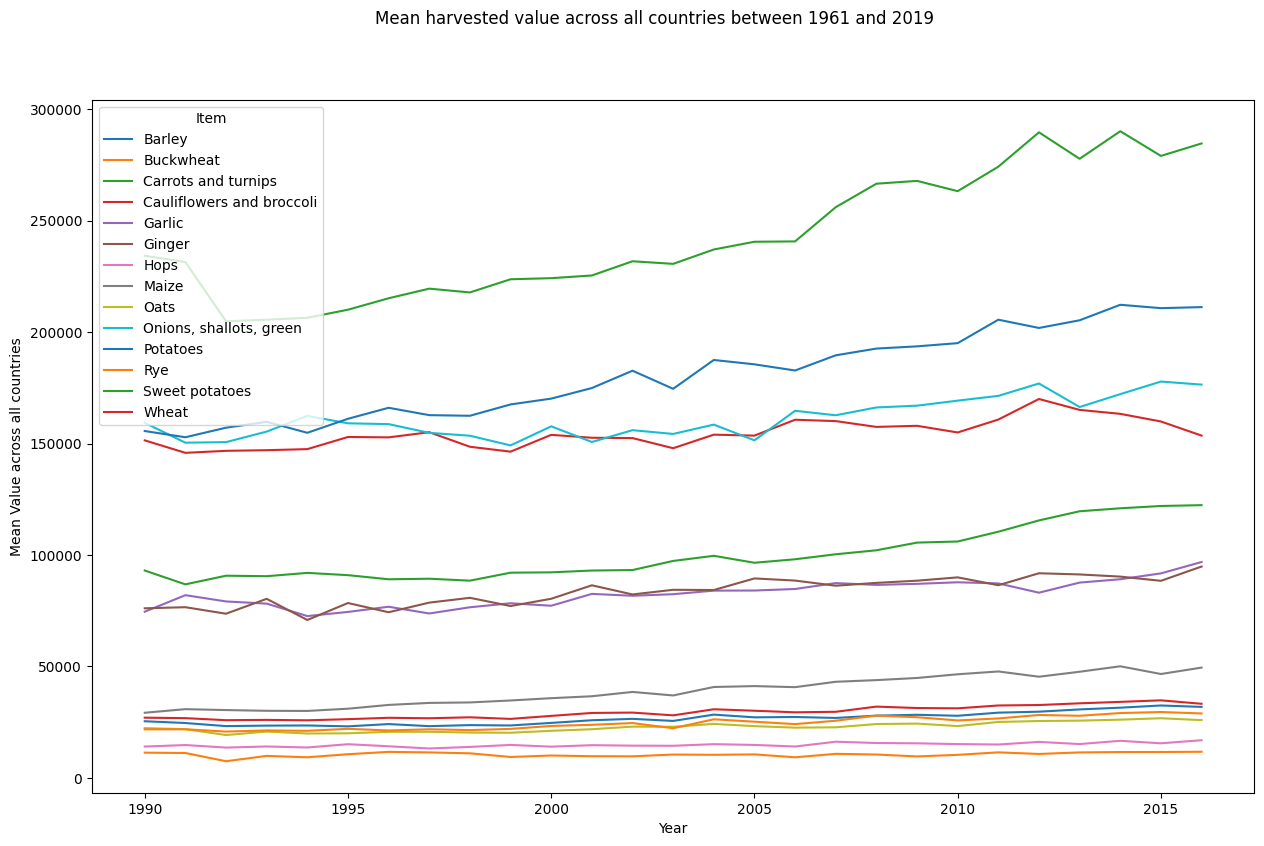

In [50]:
# prepare data
temp_data = data.groupby(['Year', 'Item']).mean(numeric_only=True)

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean harvested value across all countries between 1961 and 2019')

temp_data['Yield (hg/ha)'].unstack().plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

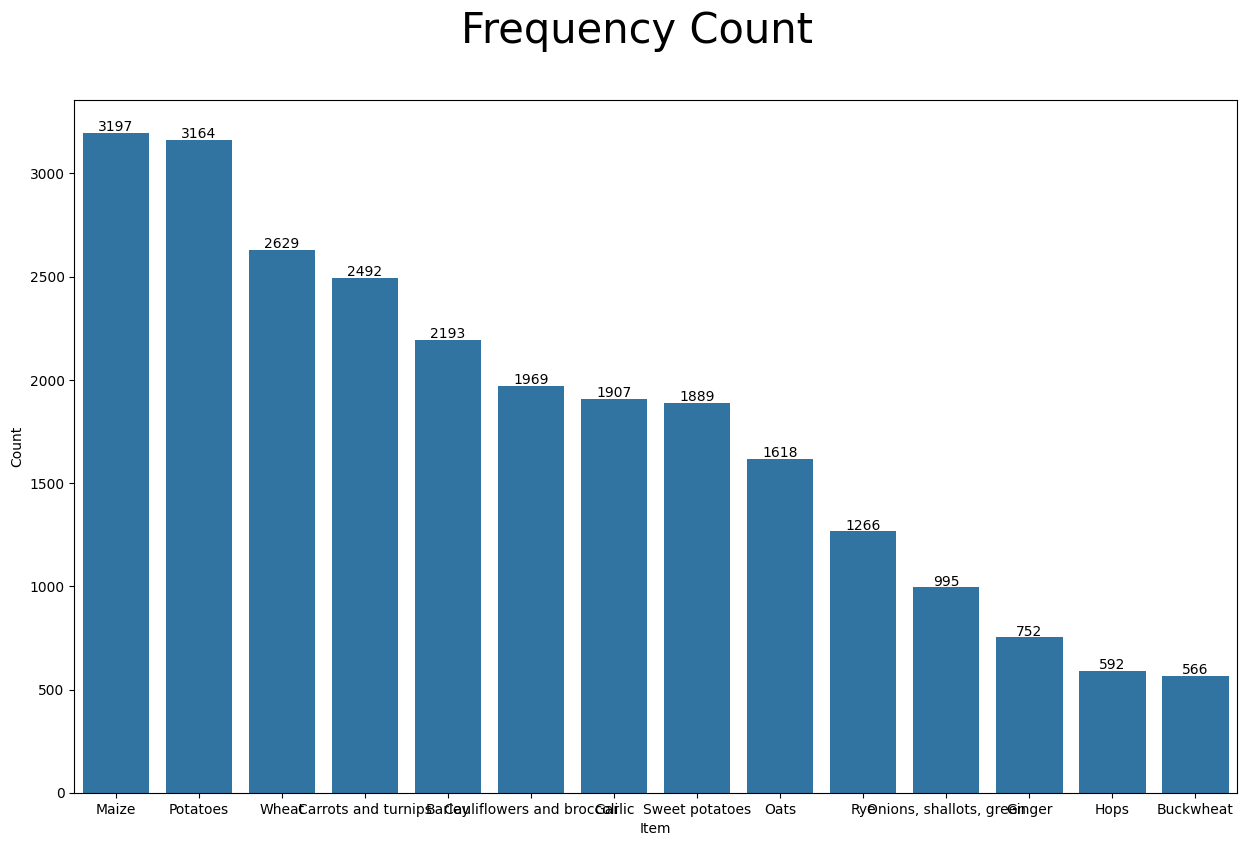

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 1, figsize=(15, 9))
fig.suptitle('Frequency Count', size=30)

# Fix value_counts dataframe
temp_df = data['Item'].value_counts().reset_index()
temp_df.columns = ['Item', 'Count']

# Plot
g = sns.barplot(x='Item', y='Count', data=temp_df, ax=axs)

# Add labels
for i, row in temp_df.iterrows():
    g.text(i, row['Count'] + 10, row['Count'], ha='center', color='black')

axs.set_xlabel('Item')
axs.set_ylabel('Count')

plt.show()

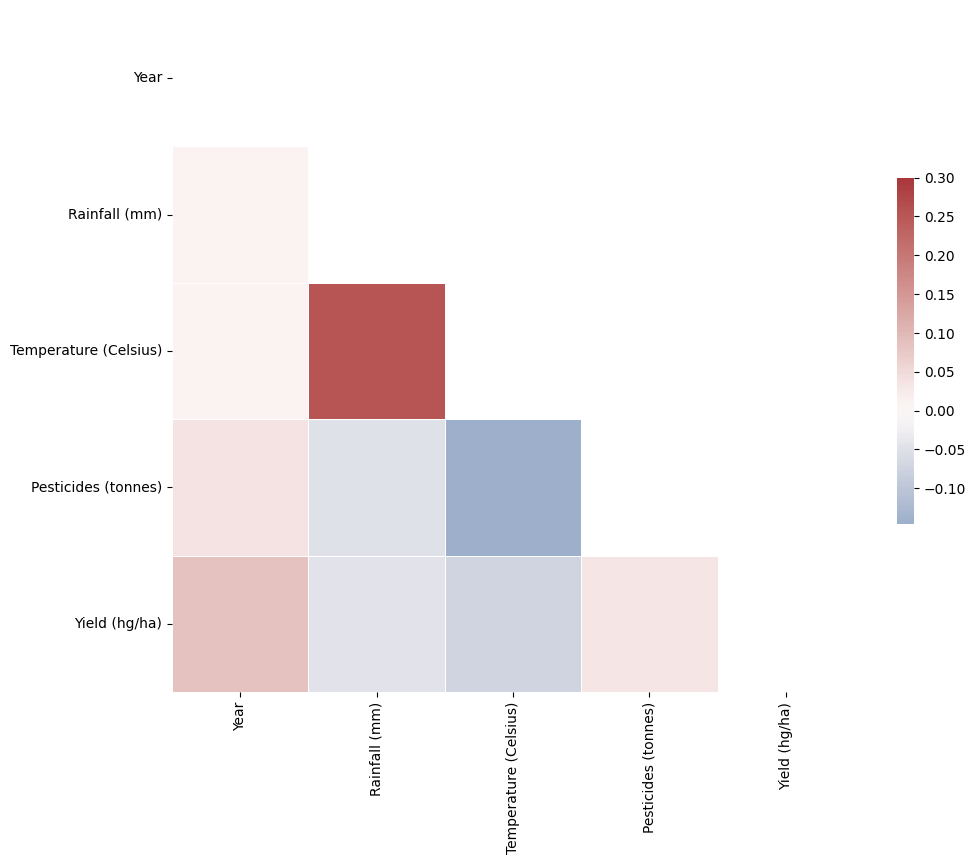

In [52]:
corr = data.select_dtypes(include=[np.number]).corr()

mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.palette="vlag"

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5});

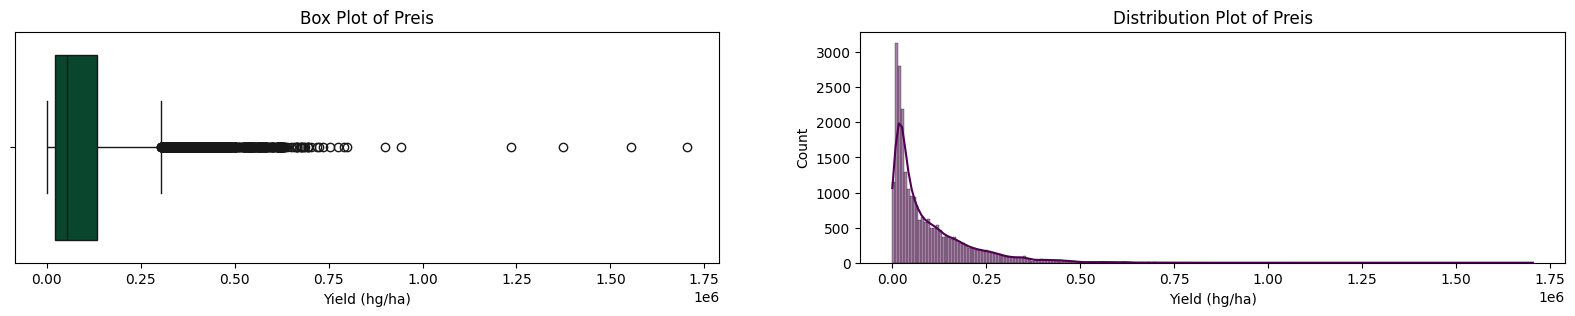

In [53]:
plt.figure(figsize=(20,3))

plt.subplot(1,2,1)
sns.boxplot(x=data['Yield (hg/ha)'],color='#005030')
plt.title(f'Box Plot of Preis')

plt.subplot(1,2,2)
sns.histplot(x=data['Yield (hg/ha)'], color='#500050', kde=True)
plt.title(f'Distribution Plot of Preis')
plt.show()

# Data Preprocessing

## One Hot Encoding

In [54]:
data.shape

(25229, 7)

In [55]:
from sklearn.preprocessing import OneHotEncoder

df_onehot = pd.get_dummies(data, columns=['Country', 'Item'], prefix=['Country', 'Item'])
data = df_onehot.loc[:, df_onehot.columns != 'Yield (hg/ha)']
data['Yield (hg/ha)'] = df_onehot['Yield (hg/ha)']

In [56]:
data.shape

(25229, 154)

## Backward Elimination

In [57]:
data.shape

(25229, 154)

In [58]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Target
y = data['Yield (hg/ha)']

# Features
X = data.drop('Yield (hg/ha)', axis=1)

# Convert categorical → dummies
X = pd.get_dummies(X, drop_first=True)

#  FORCE everything to numeric (very important)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Combine and clean
df = pd.concat([X, y], axis=1)

# Drop NaN + inf values
df = df.replace([np.inf, -np.inf], np.nan).dropna()

X = df.drop('Yield (hg/ha)', axis=1)
y = df['Yield (hg/ha)']

#FORCE numpy float (this fixes stubborn object dtype issues)
X = X.astype(float)
y = y.astype(float)

# Backward elimination
cols = list(X.columns)

while len(cols) > 0:
    X_1 = X[cols]
    X_1 = sm.add_constant(X_1)

    model = sm.OLS(y, X_1).fit()

    pvalues = model.pvalues.iloc[1:]
    pmax = pvalues.max()

    if pmax > 0.05:
        cols.remove(pvalues.idxmax())
    else:
        break

# Final dataset
data = X[cols].copy()
data['Yield (hg/ha)'] = y

data.head()

,Year,Pesticides (tonnes),Country_Algeria,Country_Angola,Country_Antigua and Barbuda,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,...,Item_Ginger,Item_Hops,Item_Maize,Item_Oats,"Item_Onions, shallots, green",Item_Potatoes,Item_Rye,Item_Sweet potatoes,Item_Wheat,Yield (hg/ha)
0,1990.0,121.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10000.0
1,1990.0,121.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150000.0
2,1990.0,121.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,171429.0
3,1990.0,121.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65000.0
4,1990.0,121.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,36613.0


In [59]:
data.shape

(25229, 128)

## Removing of Outliers

In [60]:
data.shape

(25229, 128)

In [61]:
from scipy import stats

y = data['Yield (hg/ha)']
X = data.drop('Yield (hg/ha)', axis=1)

z_scores = stats.zscore(X)
abs_z_scores = np.abs(z_scores)

filtered_entries = (abs_z_scores < 11).all(axis=1)
X = X[filtered_entries]

X.insert(len(X.columns), 'Yield (hg/ha)', y)
data = X

In [62]:
data.shape

(18345, 128)

## Feature Scaling

In [63]:
data.shape

(18345, 128)

In [64]:
from sklearn.preprocessing import MinMaxScaler

y = data['Yield (hg/ha)']
X = data.drop('Yield (hg/ha)', axis=1)

scaler = MinMaxScaler()
data_without_yield = pd.DataFrame(scaler.fit_transform(X), index=y.index)
data_without_yield.columns = X.columns
data_without_yield.insert(len(data_without_yield.columns), 'Yield (hg/ha)', y)

data = data_without_yield

In [65]:
data.shape

(18345, 128)

# Modeling

In [66]:
y = data['Yield (hg/ha)']
X = data.drop('Yield (hg/ha)', axis=1)

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [69]:
def plot_regression_results(ax, y_test, y_pred, title, estimated_time, scores):

  # linear least-squares
  slope, intercept, rvalue, pvalue, stderr = linregress(y_test, y_pred)
  ax.plot([y_test.min(), y_test.max()], [intercept+y_test.min()*slope, intercept+y_test.max()*slope], '--r')

  ax.scatter(y_test, y_pred, alpha=0.7)

  # Anzeigen der Werte in einer Box
  extra = plt.Rectangle((0, 0), 0, 0, fc="w", fill=False,
                          edgecolor='none', linewidth=0)
  ax.legend([extra], [scores], loc='upper left')

  ax.set_xlabel('Actual values in tonnes')
  ax.set_ylabel('Predictes values in tonnes')
  ax.set_title('{}\nTrained in {:.2f} Milliseconds'.format(name, estimated_time*1000))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 420
[LightGBM] [Info] Number of data points in the train set: 14676, number of used features: 71
[LightGBM] [Info] Start training from score 101046.769556


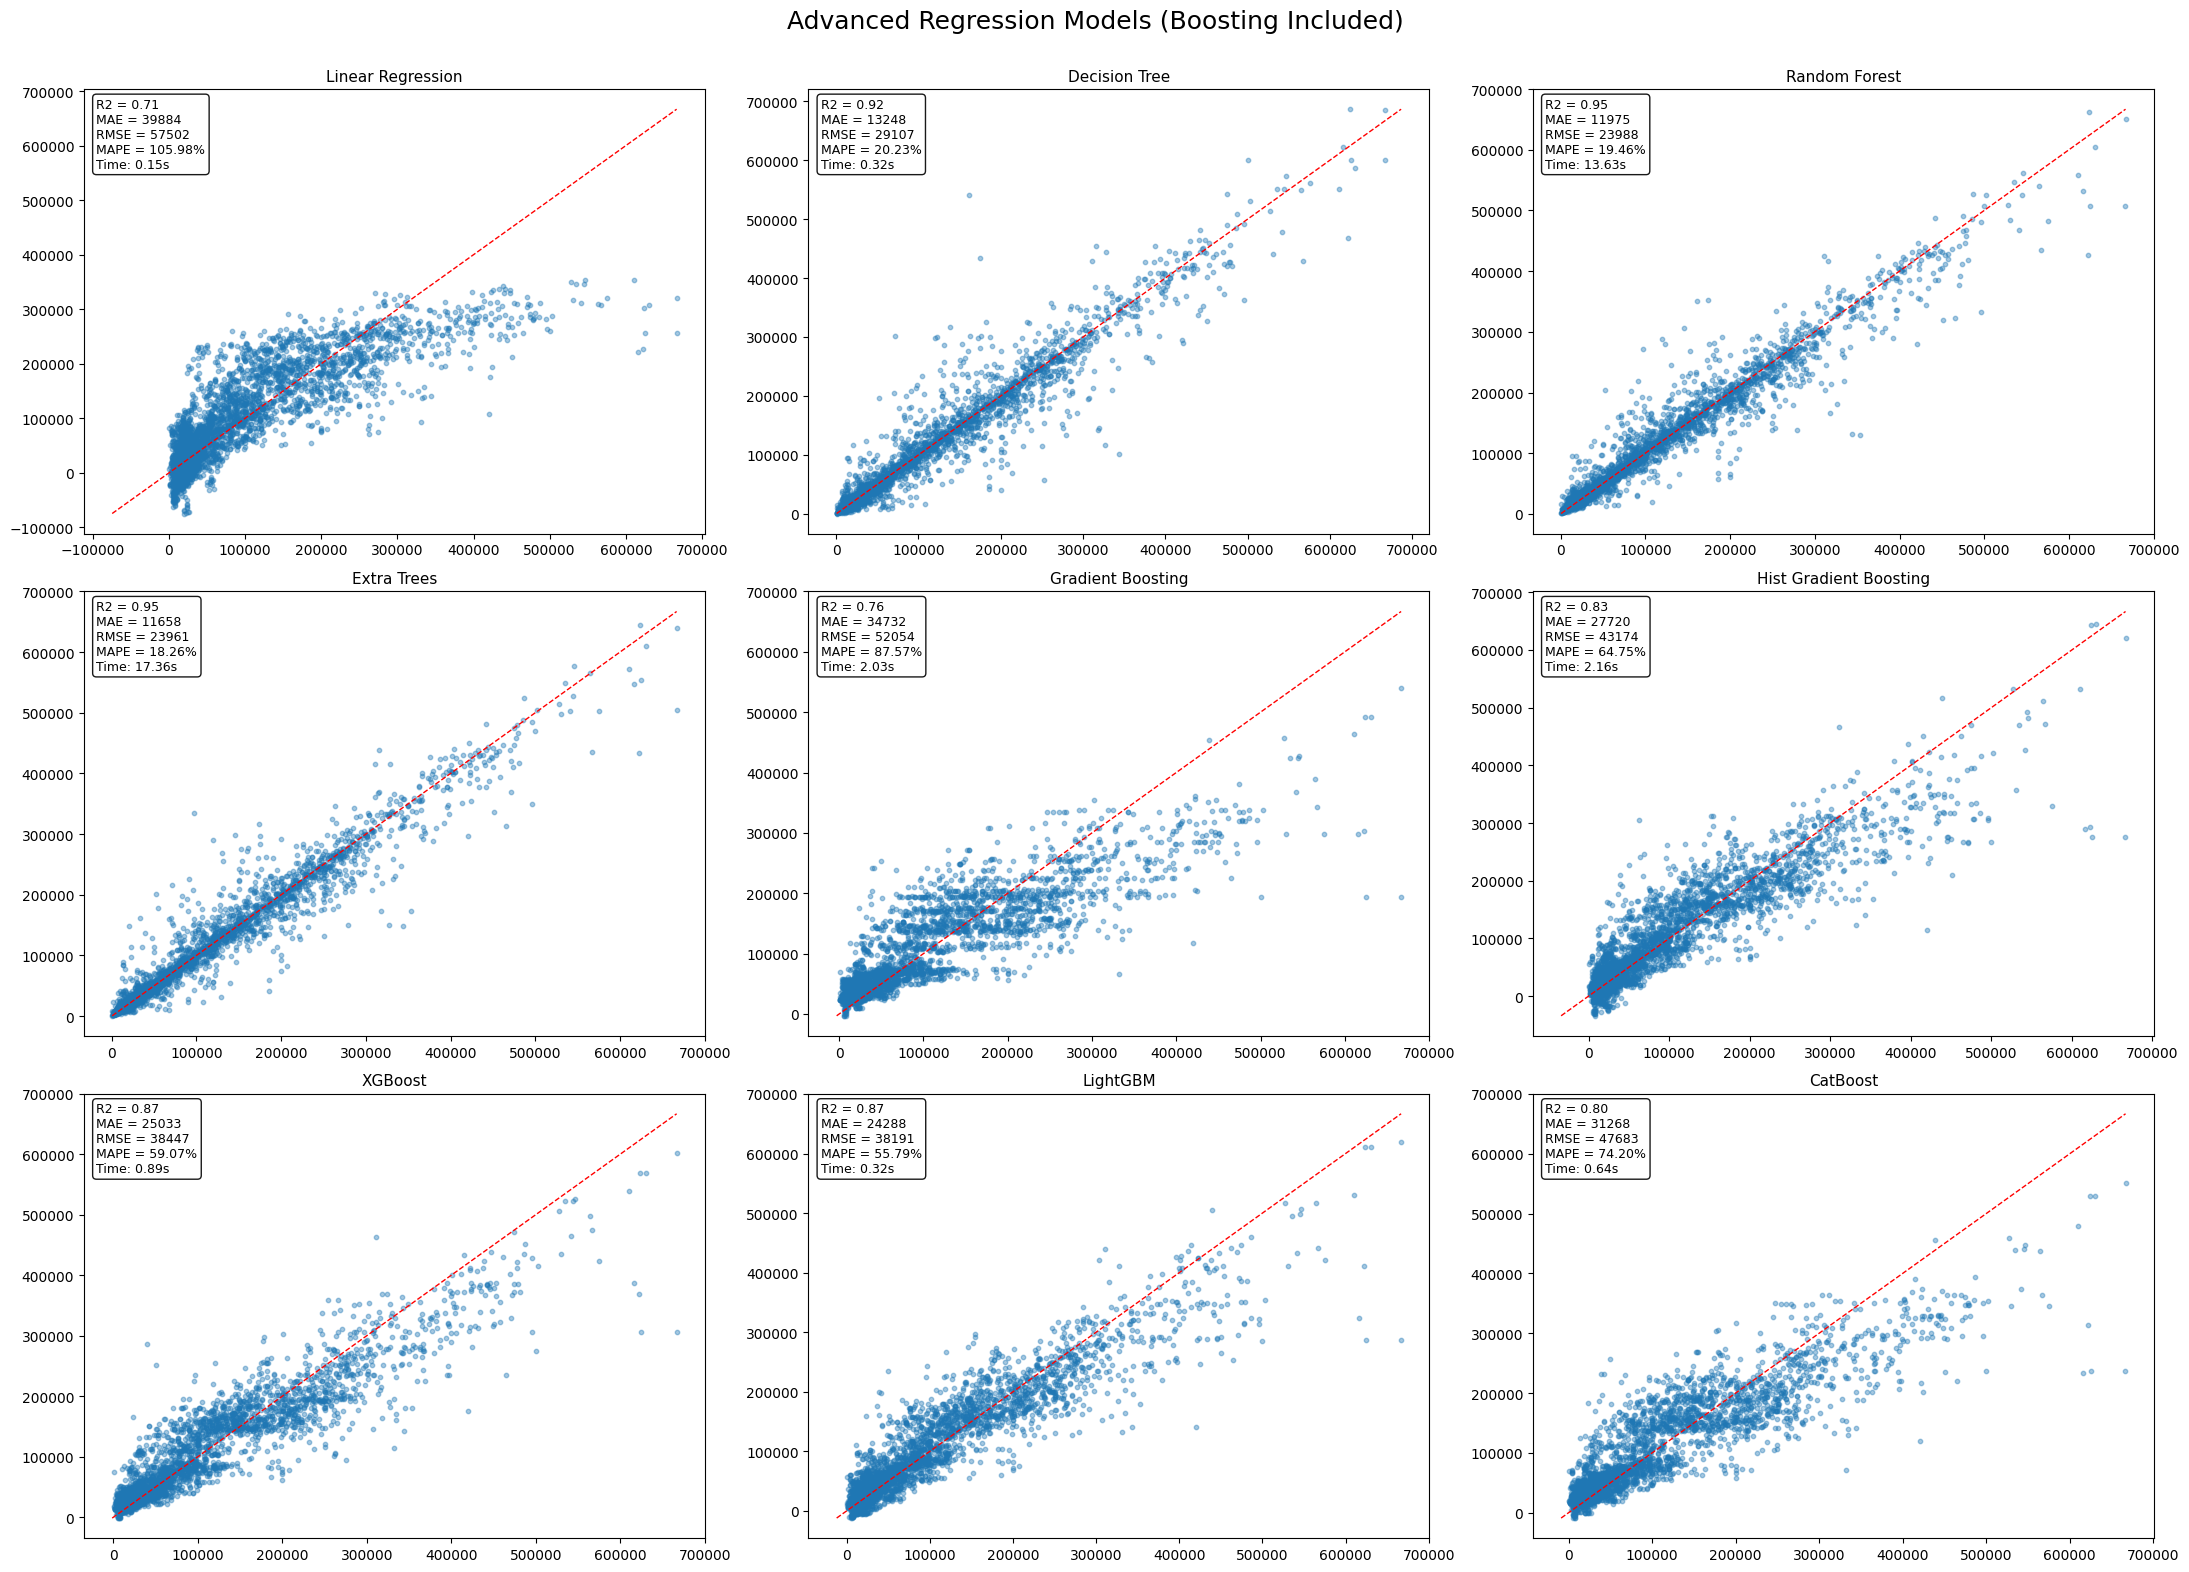


 MODEL COMPARISON TABLE:
                    Model        R2           MAE           MSE          RMSE  \
3             Extra Trees  0.948992  11658.129707  5.741093e+08  23960.579047   
2           Random Forest  0.948875  11974.999586  5.754218e+08  23987.950361   
1           Decision Tree  0.924726  13248.393568  8.472189e+08  29107.025549   
7                LightGBM  0.870408  24287.897938  1.458580e+09  38191.366629   
6                 XGBoost  0.868668  25033.431376  1.478160e+09  38446.843888   
5  Hist Gradient Boosting  0.834388  27719.613489  1.863995e+09  43174.003683   
8                CatBoost  0.797989  31268.102890  2.273668e+09  47682.994021   
4       Gradient Boosting  0.759258  34731.629157  2.709598e+09  52053.800419   
0       Linear Regression  0.706223  39883.820430  3.306514e+09  57502.292123   

       Max Error    MAPE (%)   Time (s)  
3  237854.500000   18.264701  17.362366  
2  222566.800000   19.463064  13.631649  
1  529707.000000   20.229340   0.3176

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

!pip install catboost lightgbm xgboost -q

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    max_error,
    mean_absolute_percentage_error
)

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# ---------------------------
# Clean column names (important for LightGBM)
# ---------------------------
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace('[^A-Za-z0-9_]', '_', regex=True)
        .str.replace('__+', '_', regex=True)
    )
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)

# ---------------------------
# Plot function
# ---------------------------
def plot_regression_results(ax, y_true, y_pred, title, time_taken, metrics_text):
    ax.scatter(y_true, y_pred, alpha=0.4, s=10)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

    ax.set_title(title, fontsize=11)

    ax.text(
        0.02, 0.98,
        metrics_text + f"\nTime: {time_taken:.2f}s",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

# ---------------------------
# Models
# ---------------------------
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor()),
    ('Random Forest', RandomForestRegressor()),
    ('Extra Trees', ExtraTreesRegressor()),
    ('Gradient Boosting', GradientBoostingRegressor()),
    ('Hist Gradient Boosting', HistGradientBoostingRegressor()),
    ('XGBoost', XGBRegressor(n_estimators=200, learning_rate=0.05, verbosity=0)),
    ('LightGBM', LGBMRegressor(n_estimators=200, learning_rate=0.05)),
    ('CatBoost', CatBoostRegressor(iterations=200, learning_rate=0.05, verbose=0))
]

# ---------------------------
# Plot setup
# ---------------------------
rows, cols = 3, 3
fig, axs = plt.subplots(rows, cols, figsize=(22, 16))
axs = np.ravel(axs)

# ---------------------------
# Store results
# ---------------------------
results = []
predictions_df = pd.DataFrame({"Actual": y_test.reset_index(drop=True)})

# ---------------------------
# Training loop
# ---------------------------
for ax, (name, model) in zip(axs, models):
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    elapsed = time.time() - start

    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    max_err = max_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Max Error": max_err,
        "MAPE (%)": mape * 100,
        "Time (s)": elapsed
    })

    # Store predictions
    predictions_df[name] = y_pred

    # Plot text
    metrics_text = (
        f"R2 = {r2:.2f}\n"
        f"MAE = {mae:.0f}\n"
        f"RMSE = {rmse:.0f}\n"
        f"MAPE = {mape*100:.2f}%"
    )

    plot_regression_results(ax, y_test, y_pred, name, elapsed, metrics_text)

# Remove extra plots
for i in range(len(models), len(axs)):
    fig.delaxes(axs[i])

plt.suptitle('Advanced Regression Models (Boosting Included)', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.93)

# Save plot
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

# ---------------------------
# Create results DataFrame
# ---------------------------
results_df = pd.DataFrame(results)

# Sort best model
results_df = results_df.sort_values(by="R2", ascending=False)

# Save CSV
results_df.to_csv("model_results.csv", index=False)
predictions_df.to_csv("model_predictions.csv", index=False)

print("\n MODEL COMPARISON TABLE:")
print(results_df)

print("\n BEST MODEL:", results_df.iloc[0]["Model"])

# ---------------------------
# (Optional) Download in Colab
# ---------------------------
try:
    from google.colab import files
    files.download("model_results.csv")
    files.download("model_predictions.csv")
    files.download("model_comparison.png")
except:
    pass

R2: 0.948461485901363
RMSE: 24084.7492307797


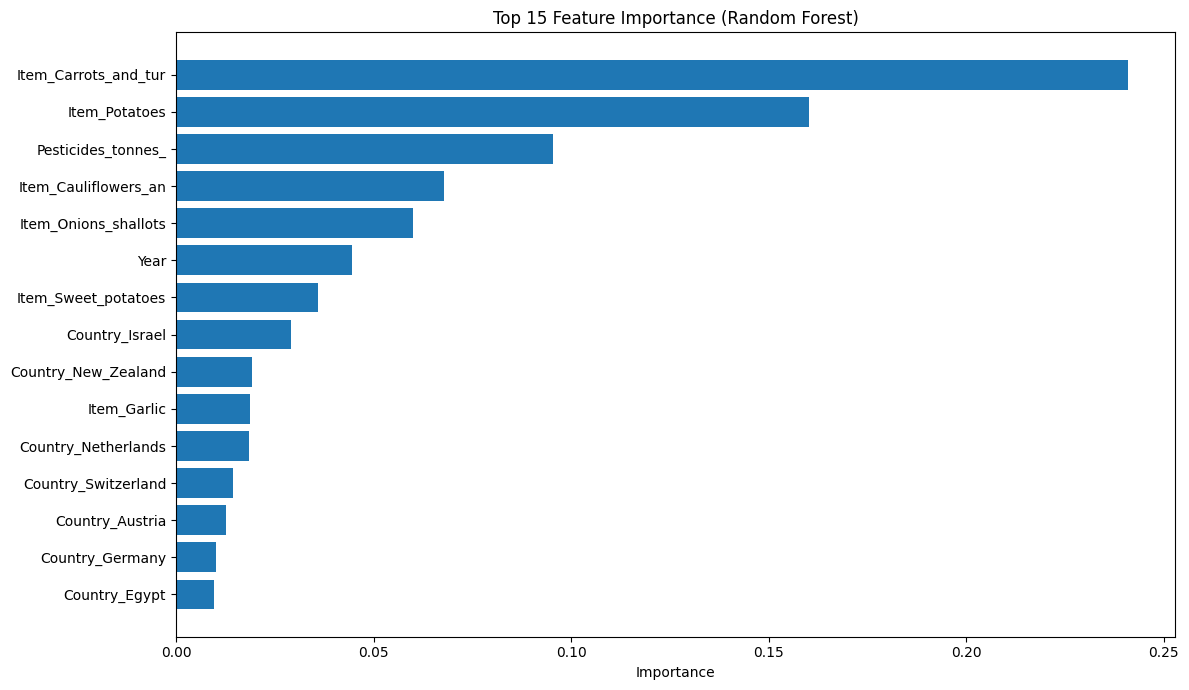

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------
# Train BEST model (Random Forest)
# ---------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ---------------------------
# Metrics
# ---------------------------
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# ---------------------------
# 1. Feature Importance (TOP 15)
# ---------------------------
top_n = 15

importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:top_n]

feature_names = X_train.columns[indices].astype(str)
feature_names = [name[:20] for name in feature_names]

plt.figure(figsize=(12, 7))
plt.title("Top 15 Feature Importance (Random Forest)")

plt.barh(range(top_n), importances[indices][::-1])
plt.yticks(range(top_n), feature_names[::-1])

plt.xlabel("Importance")
plt.tight_layout()

# SAVE PNG
plt.savefig("feature_importance_top15.png", dpi=300, bbox_inches='tight')

plt.show()

# ---------------------------
# 2. SHAP (Explainable AI)
# ---------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Clean feature names for SHAP
X_test_clean = X_test.copy()
X_test_clean.columns = [str(col)[:18] for col in X_test.columns]

# ---------------------------
# 3. SHAP Summary (TOP 15)
# ---------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_clean,
    max_display=15,
    show=False
)
plt.title("SHAP Summary (Top 15 Features)")

plt.savefig("shap_summary_top15.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------
# 4. SHAP Feature Importance (BAR)
# ---------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_clean,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance (Top 15)")

plt.savefig("shap_bar_top15.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------
# 5. Local Explanation (Single Prediction)
# ---------------------------
idx = 0  # change sample

plt.figure()
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    X_test_clean.iloc[idx]
)

plt.title(f"SHAP Waterfall (Sample {idx})")

plt.savefig("shap_waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------
# (Optional) Download in Colab
# ---------------------------
try:
    from google.colab import files
    files.download("feature_importance_top15.png")
    files.download("shap_summary_top15.png")
    files.download("shap_bar_top15.png")
    files.download("shap_waterfall.png")
except:
    pass